# Exploring Data and Training

This notebook contains the EDA code and results, and also the training code of several models. 

The environment to use is specified in pyproject.toml (install it using uv). It does not require GPU.


## Useful imports

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split, KFold
from scipy.stats import uniform, randint
from sklearn.ensemble import RandomForestRegressor

import joblib
import umap

from nn_model import NNRegressor
from torch.utils.data import DataLoader, TensorDataset
import torch

## First glimpse at the dataset

First, we import the data (with correct types):

In [3]:
df_path = "../data/data_challenge.csv"
df = pd.read_csv(df_path, sep=";")
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df["Take-off Time (UTC)"] = pd.to_datetime(
    df["Take-off Time (UTC)"], format="%d/%m/%Y %H:%M"
)
df

,Aircraft,Engine,Role,Registration,Seats,Cargo Capacity (t),Flight Number,Date,Take-off Time (UTC),Origin Airport,Destination Airport,Distance OD (km),Distance Flown (km),CO2 (kgCO2e),Contrails (kgCO2e)
0,A20N,PW1127G-JM,PAX,EC-NFH,186.0,0.0,VY7835,2023-06-15,2023-06-15 16:01:00,EGKK,LEBL,1109.053917,1155.727519,11253.969499,0.000000
1,A20N,PW1127G-JM,PAX,EC-NIJ,186.0,0.0,VY7830,2023-06-15,2023-06-15 05:12:00,LEBL,EGKK,1109.053917,1255.367953,11965.946434,16370.295266
2,A20N,PW1127G-JM,PAX,EC-NCT,186.0,0.0,VY3212,2023-12-31,2023-12-31 10:52:00,LEBL,GCXO,2194.502853,NaN,19808.910939,NaN
3,A20N,PW1127G-JM,PAX,EC-NCF,186.0,0.0,VY6213,2023-10-09,2023-10-09 15:49:00,LEMG,LIRF,1548.024410,1590.238353,14352.387644,41217.801880
4,A321,CFM56-5B3/3,PAX,EC-NLY,220.0,0.0,VY8748,2023-11-02,2023-11-02 13:50:00,EGCC,LEBL,1379.156221,1492.741633,20147.168918,11686.423628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,A321,V2533-A5,PAX,EC-MOO,220.0,0.0,VY6937,2023-07-28,2023-07-28 13:44:00,LEIB,LFPO,1098.264174,1234.678762,17236.971394,0.000000
19996,A320,V2527-A5,PAX,EC-MEQ,186.0,0.0,VY3293,2023-09-04,2023-09-04 17:18:00,EKCH,EHVK,634.882463,NaN,10097.686470,NaN
19997,A321,V2533-A5,PAX,EC-MQL,220.0,0.0,VY1883,2023-02-13,2023-02-13 20:41:00,EDDB,LEBL,1502.412483,1568.138924,21013.515601,0.000000
19998,A20N,PW1127G-JM,PAX,EC-NDC,186.0,0.0,VY2112,2023-02-25,2023-02-25 18:39:00,LEMG,LEBL,765.966390,876.445651,9263.071031,0.000000


Check for useless features/entries.

In [4]:
# drop useless columns
df = df.drop(columns=["Cargo Capacity (t)", "Role"])


# count nan values per column
print(df.isna().sum())
df = df.dropna()

Aircraft                 0
Engine                   0
Registration             0
Seats                    0
Flight Number            0
Date                     0
Take-off Time (UTC)      0
Origin Airport           0
Destination Airport      0
Distance OD (km)         1
Distance Flown (km)    671
CO2 (kgCO2e)             1
Contrails (kgCO2e)     671
dtype: int64


We have a look at the Contrails impact distribution.

In [5]:
px.histogram(df, x="Contrails (kgCO2e)")

The distribution seems unbalanced. From now, we will ignore all the flights that have exactly 0 contrail impact.

In [6]:
px.histogram(df.where(df["Contrails (kgCO2e)"] != 0), x="Contrails (kgCO2e)")

In [7]:
# count rows where Contrails (kgCO2e) is 0, and get rid of them
print(df[df["Contrails (kgCO2e)"] == 0].shape[0])
print(len(df))
df = df[df["Contrails (kgCO2e)"] != 0]
print(len(df))

12344
19329
6985


To anticipate model training, we encode the categorical features.

In [8]:
categorical_features = [
    "Aircraft",
    "Engine",
    "Registration",
    "Flight Number",
    "Origin Airport",
    "Destination Airport",
]
numerical_features = df.columns.difference(categorical_features)


encoder = OrdinalEncoder()
categorical_data = encoder.fit_transform(df[categorical_features])


categorical_data = pd.DataFrame(categorical_data, columns=categorical_features).dropna()


data = pd.concat([df[numerical_features], categorical_data], axis=1).dropna()
data

,CO2 (kgCO2e),Contrails (kgCO2e),Date,Distance Flown (km),Distance OD (km),Seats,Take-off Time (UTC),Aircraft,Engine,Registration,Flight Number,Origin Airport,Destination Airport
1,11965.946434,16370.295266,2023-06-15,1255.367953,1109.053917,186.0,2023-06-15 05:12:00,0.0,5.0,103.0,544.0,46.0,94.0
3,14352.387644,41217.801880,2023-10-09,1590.238353,1548.024410,186.0,2023-10-09 15:49:00,3.0,7.0,46.0,248.0,59.0,47.0
4,20147.168918,11686.423628,2023-11-02,1492.741633,1379.156221,220.0,2023-11-02 13:50:00,3.0,1.0,21.0,565.0,66.0,94.0
10,10632.932103,434360.293772,2023-02-13,787.970150,701.154153,180.0,2023-02-13 20:38:00,3.0,1.0,22.0,531.0,96.0,48.0
13,14932.163157,1518.480424,2023-04-28,1247.983036,1088.665991,180.0,2023-04-28 07:20:00,3.0,1.0,18.0,929.0,40.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6951,7061.216434,61717.662191,2023-01-02,566.307141,453.468536,186.0,2023-01-02 21:13:00,0.0,5.0,107.0,188.0,42.0,48.0
6965,16399.772151,537096.819247,2023-10-01,1405.901790,1241.136244,180.0,2023-10-01 16:30:00,0.0,5.0,118.0,134.0,5.0,48.0
6969,20146.491584,15767.109699,2023-03-22,1807.618967,1645.205998,180.0,2023-03-22 06:02:00,3.0,7.0,42.0,47.0,17.0,44.0
6974,8543.747535,5226.820196,2023-11-29,563.371344,453.468536,180.0,2023-11-29 15:29:00,0.0,5.0,108.0,51.0,40.0,47.0


In [9]:
data.describe()

,CO2 (kgCO2e),Contrails (kgCO2e),Date,Distance Flown (km),Distance OD (km),Seats,Take-off Time (UTC),Aircraft,Engine,Registration,Flight Number,Origin Airport,Destination Airport
count,2407.000000,2.407000e+03,2407,2407.000000,2407.000000,2407.000000,2407,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000,2407.000000
mean,15746.860923,4.108165e+04,2023-06-29 00:32:18.346489344,1361.944551,1255.274886,188.009971,2023-06-29 13:07:35.471541248,2.523473,4.874533,64.118405,464.562111,45.444121,52.022850
min,7061.216434,-7.379588e+05,2023-01-01 00:00:00,456.090348,0.000000,144.000000,2023-01-01 05:19:00,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
25%,12100.541097,-1.635407e+03,2023-04-09 00:00:00,958.778237,854.821215,180.000000,2023-04-09 07:14:30,2.000000,2.000000,33.000000,173.000000,35.000000,36.000000
50%,14780.329054,5.309812e+02,2023-06-09 00:00:00,1268.656798,1109.053917,186.000000,2023-06-09 04:59:00,3.000000,5.000000,65.000000,474.000000,40.000000,48.000000
75%,17953.711087,2.732005e+04,2023-10-04 00:00:00,1603.627850,1485.689825,186.000000,2023-10-04 07:14:30,3.000000,7.000000,94.000000,757.000000,59.000000,68.000000
max,43357.136145,2.150571e+06,2023-12-31 00:00:00,4151.327430,3849.304846,230.000000,2023-12-31 17:22:00,4.000000,8.000000,125.000000,972.000000,97.000000,109.000000
std,5185.960909,1.520994e+05,NaN,529.363474,518.541106,18.068676,NaN,1.313721,2.581998,35.540999,308.793576,22.853488,24.883834


Finally, let's have a look to correlations between features. The line of interest in this plot is the second one : "Contrails (kgCO2)".

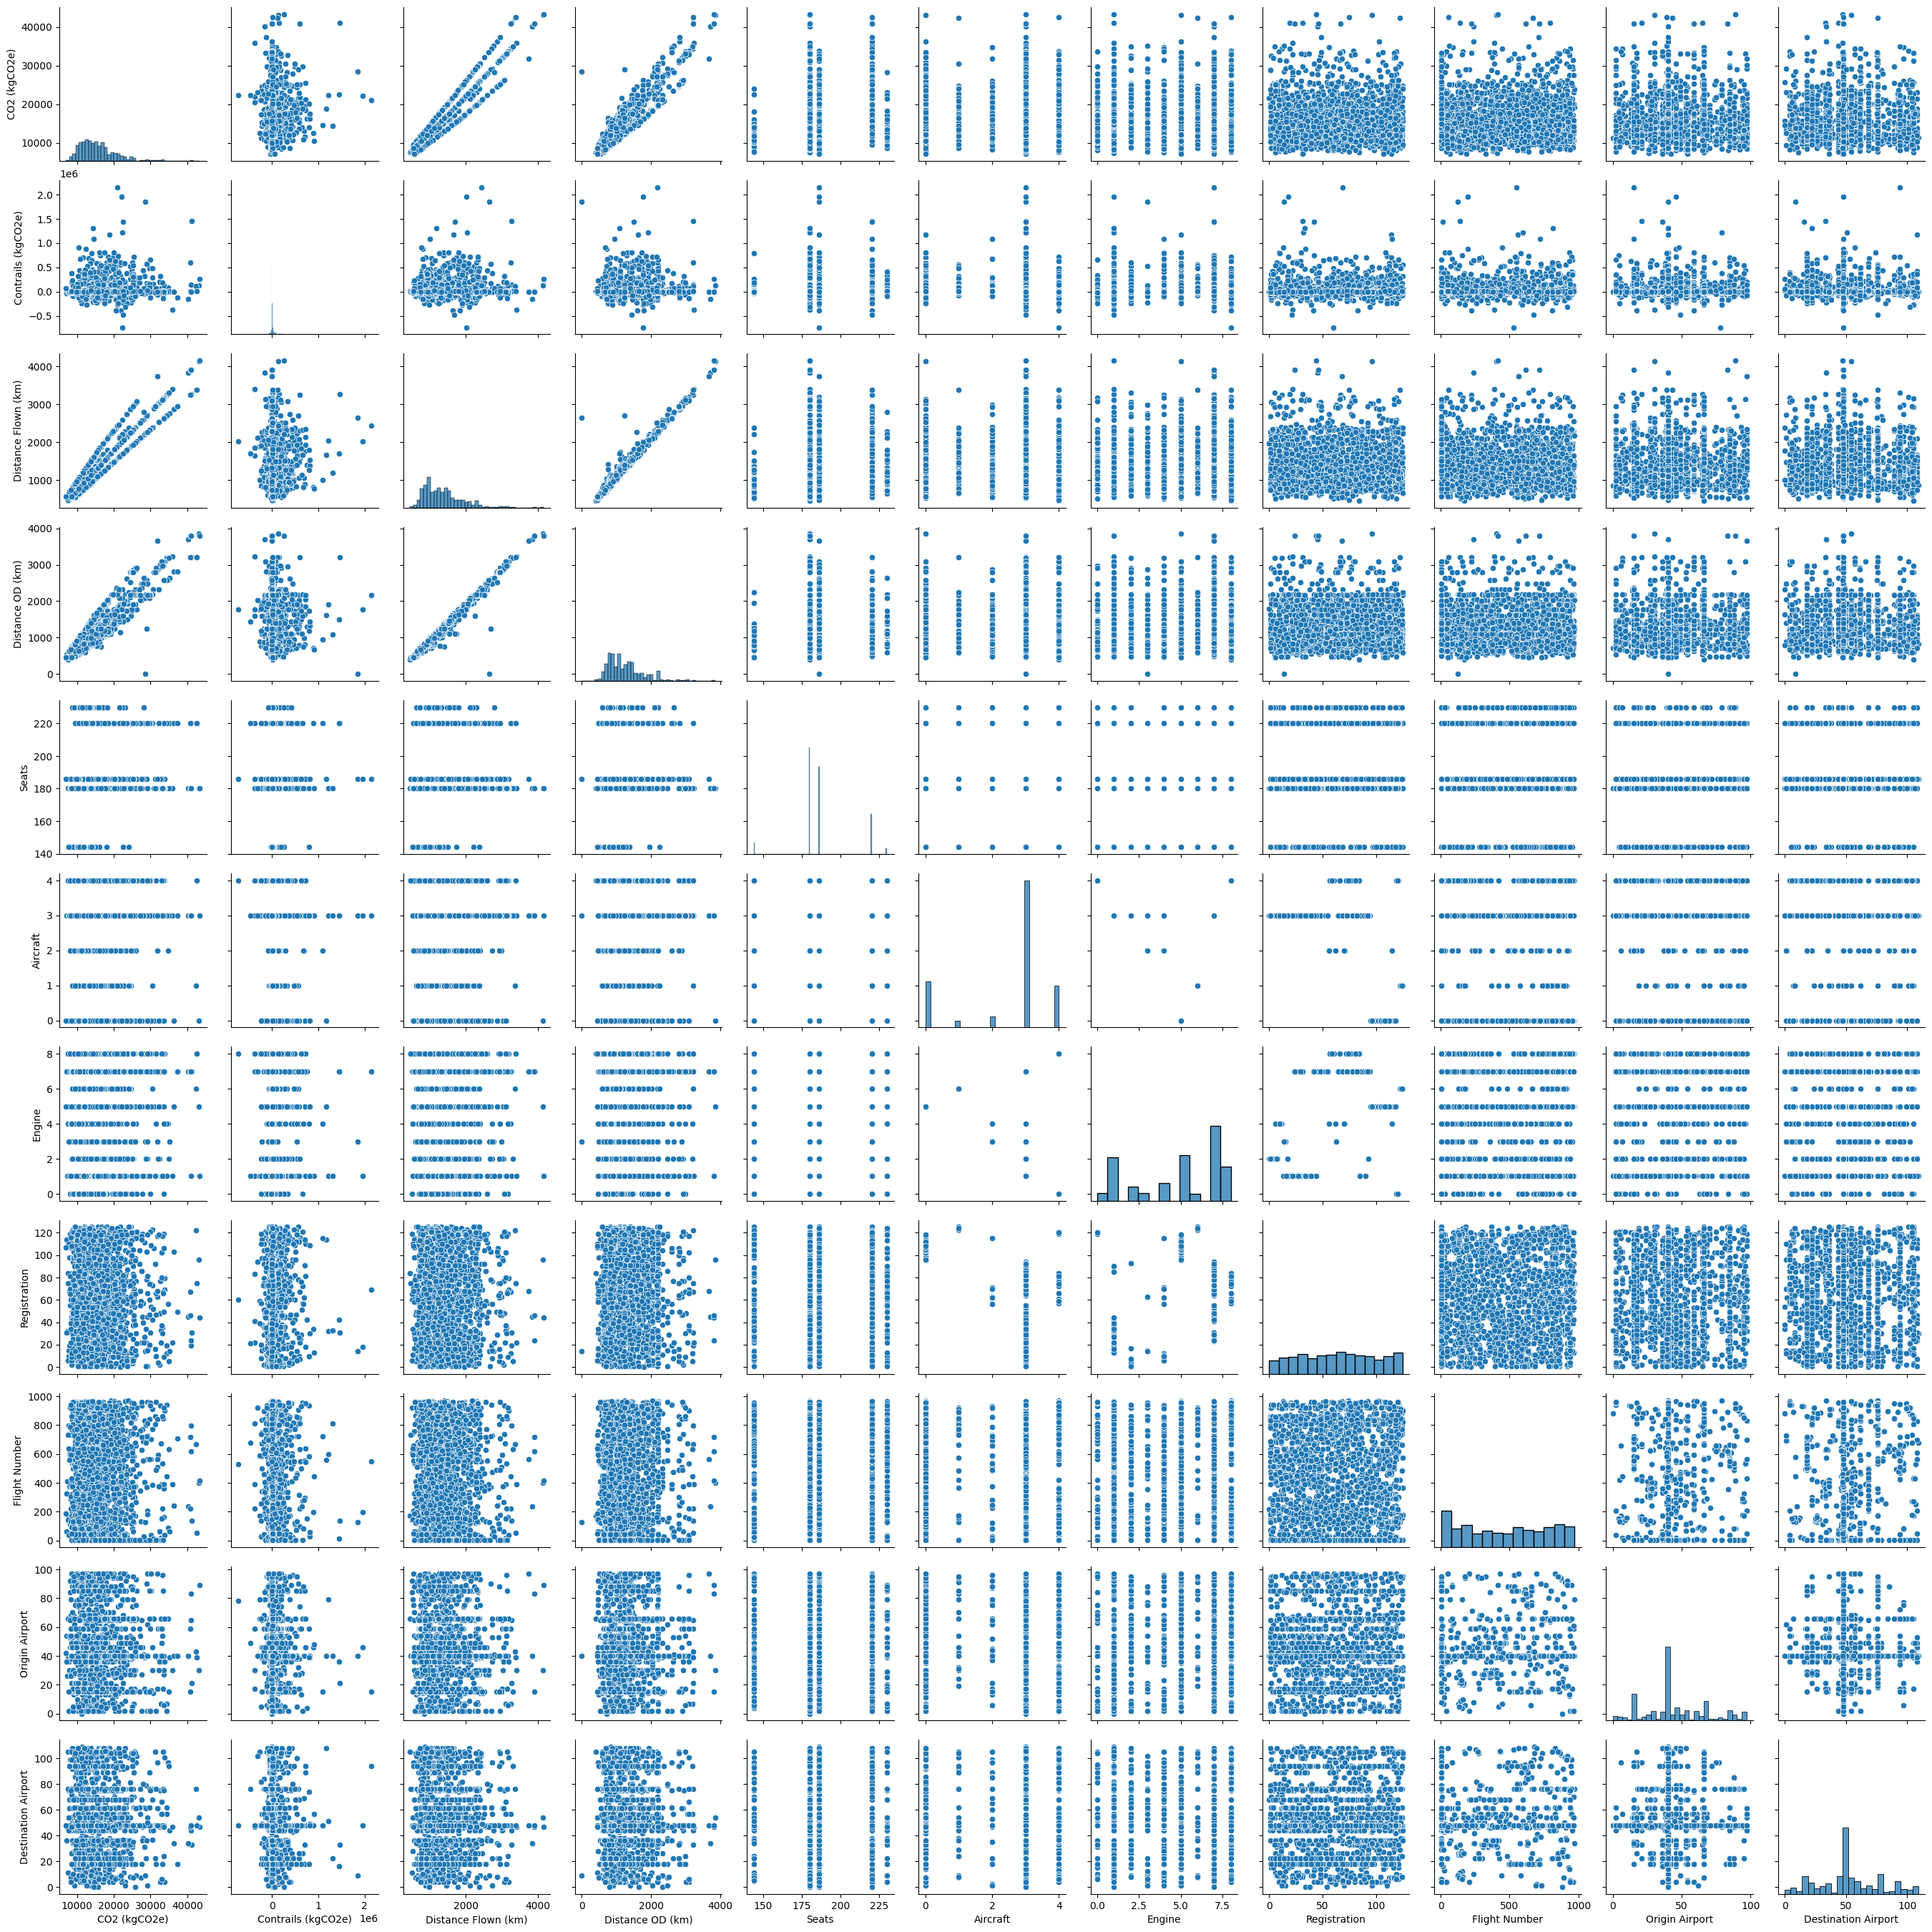

In [10]:
sns.pairplot(data)

From this plot we cannot really distinguish an obvious correlation between a feature and Contrail Impact. We will try to get some explainability with dimension reduction methods.

## PCA

PCA will highlight linear relations between features.

In [11]:
data_pre_pca = data.drop(columns=["Contrails (kgCO2e)"])
n_components = len(data_pre_pca.columns)
pca = PCA(n_components=n_components)

x_norm = ((data_pre_pca - data_pre_pca.mean()) / data_pre_pca.std()).values

data_pca = pca.fit_transform(x_norm)
data["PC1"] = data_pca[:, 0]
data["PC2"] = data_pca[:, 1]
data["PC3"] = data_pca[:, 2]

# 3D PCA plot

fig0 = px.scatter_3d(
    data,
    x="PC1",
    y="PC2",
    z="PC3",
    height=800,
    width=800,
    color="Contrails (kgCO2e)",
    color_continuous_scale=px.colors.diverging.Portland,
).update_traces(marker=dict(size=2))


fig0.show()

# 2D PCA plot
fig1 = px.scatter(
    data,
    x="PC1",
    y="PC2",
    color="Contrails (kgCO2e)",
    color_continuous_scale=px.colors.diverging.Portland,
)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(data_pre_pca.columns[:-3]):

    fig1.add_annotation(
        ax=0,
        ay=0,
        axref="x",
        ayref="y",
        x=loadings[i, 0],
        y=loadings[i, 1],
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top",
    )

    fig1.add_annotation(
        x=loadings[i, 0],
        y=loadings[i, 1],
        ax=0,
        ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5,
    )


fig1.show()

C:\Users\nicow\AppData\Local\Temp\ipykernel_23340\3879960457.py:5: PerformanceWarning:

Adding/subtracting object-dtype array to DatetimeArray not vectorized.

C:\Users\nicow\AppData\Local\Temp\ipykernel_23340\3879960457.py:5: PerformanceWarning:

Adding/subtracting object-dtype array to DatetimeArray not vectorized.



That is not really convincing. One cannot really see a discriminating behavior for contrail impacts. We will now vary the approaches.

## UMAP

Let's try UMAP, to get another representation. UMAP allow to get non linear transformation, that can help us getting insights before training models.

In [12]:
data_pre_umap = data.drop(columns=["Contrails (kgCO2e)"])

min_date = data_pre_umap["Date"].min()
data_pre_umap["Date"] = (
    (data_pre_umap["Date"] - min_date).dt.total_seconds() / 3600 / 24
)
data_pre_umap["Take-off Time (UTC)"] = (
    (data_pre_umap["Take-off Time (UTC)"] - min_date).dt.total_seconds() / 3600 / 24
)

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(data_pre_umap.values)
data["UMAP1"] = embedding[:, 0]
data["UMAP2"] = embedding[:, 1]
data["color_for_contrails"] = (
    data["Contrails (kgCO2e)"] - data["Contrails (kgCO2e)"].min()
)
fig2 = px.scatter(
    data,
    x="UMAP1",
    y="UMAP2",
    color="Contrails (kgCO2e)",
    size="color_for_contrails",
    color_continuous_scale=px.colors.diverging.Portland,
).update_traces(marker=dict(sizemin=2))
fig2.show()

c:\Users\nicow\OneDrive\01_job\Technical_Steps\estuaire\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\nicow\OneDrive\01_job\Technical_Steps\estuaire\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Same conclusion as PCA. One cannot really see a "logical pattern" for Contrail impact within this space.

## PLS

Last, let's try PLS (Partial Least Square) This one is close from PCA as it gives linear relations between features, but it directly tries to maximize the output value (in our case the contrail impact).

But first, we will select the most correlated features as input.

In [13]:
correlation = data.corr()
correlation["Contrails (kgCO2e)"].apply(lambda x: abs(x)).sort_values(
    ascending=False
).head(12)

color_for_contrails    1.000000
Contrails (kgCO2e)     1.000000
CO2 (kgCO2e)           0.123096
Distance Flown (km)    0.112556
PC1                    0.111199
UMAP1                  0.108664
Distance OD (km)       0.084733
Seats                  0.062356
UMAP2                  0.044019
Aircraft               0.018799
Destination Airport    0.018436
Take-off Time (UTC)    0.017095
Name: Contrails (kgCO2e), dtype: float64

CO2 impact seems to be the most correlated feature. But as I am not sure about how fair it is to use it for inference (it might not come from one of the three sources : aircraft, airport or flight), we won't use it. Now let's make a selection and run PLS.

In [14]:
feature_selection_list = [
    "Distance Flown (km)",
    "Distance OD (km)",
    "Seats",
    "Aircraft",
    "Destination Airport",
    "Take-off Time (UTC)",
    "Engine",
    "Date",
]

In [15]:
data["Contrails (kgCO2e)"].describe()

count    2.407000e+03
mean     4.108165e+04
std      1.520994e+05
min     -7.379588e+05
25%     -1.635407e+03
50%      5.309812e+02
75%      2.732005e+04
max      2.150571e+06
Name: Contrails (kgCO2e), dtype: float64

In [16]:
y = data["Contrails (kgCO2e)"]
# normalize y and apply log transformation
y = np.log(y - y.min() + 1)

pls = PLSRegression(n_components=3)
pls.fit(x_norm, y)

data["PLS_PC1"] = pls.x_scores_[:, 0]
data["PLS_PC2"] = pls.x_scores_[:, 1]
data["PLS_PC3"] = pls.x_scores_[:, 2]

# plotting the loadings
loadings = pls.x_loadings_
fig = px.scatter(
    data,
    x="PLS_PC1",
    y="PLS_PC2",
    color="Contrails (kgCO2e)",
    color_continuous_scale=px.colors.diverging.Portland,
)

for i, feature in enumerate(feature_selection_list):
    fig.add_annotation(
        ax=0,
        ay=0,
        axref="x",
        ayref="y",
        x=loadings[i, 0],
        y=loadings[i, 1],
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top",
    )
    fig.add_annotation(
        x=loadings[i, 0],
        y=loadings[i, 1],
        ax=0,
        ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5,
    )
fig.show()

Again, this is not convincing, there is too much noise. We will use all the features, in a hopefully robust and versatile model and try to predict the contrail impact.

We will try 3 models: XGBoost, Random Forest and a basic Neural Network.

## XGBoost

In [17]:
input_features = [
    "Date",
    "Distance Flown (km)",
    "Distance OD (km)",
    "Seats",
    "Take-off Time (UTC)",
    "Aircraft",
    "Engine",
    "Registration",
    "Flight Number",
    "Origin Airport",
    "Destination Airport",
]

# Calcul de la date minimale
min_date = data["Date"].min()

# Conversion des colonnes en minutes depuis la date minimale
data["Date"] = (data["Date"] - min_date).dt.total_seconds() / 3600 / 24
data["Take-off Time (UTC)"] = (
    (data["Take-off Time (UTC)"] - min_date).dt.total_seconds() / 3600 / 24
)

In [18]:
# using xgboost for regression on Contrails (kgCO2e), using data[feature_selection_list] as features
# we use cross validation to find the best parameters


X = data[input_features].values
y = data["Contrails (kgCO2e)"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# define the model
model = XGBRegressor()
# define the parameter grid for RandomizedSearchCV
param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(2, 10),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.5, 0.5),
    "colsample_bytree": uniform(0.5, 0.5),
    "gamma": uniform(0, 5),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0, 1),
}
# perform Randomized search with cross validation

grid_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
# print best parameters
print("Best parameters: ", grid_search.best_params_)
# print best score
print("Best score: ", grid_search.best_score_)
# fit the model with the best parameters
model = grid_search.best_estimator_
model.fit(X_train, y_train)
# make predictions on the test set
y_pred = model.predict(X_test)
# calculate the mean squared error and r squared
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean squared error: ", mse)
print("Root mean squared error: ", rmse)
print("R squared: ", r2)

# plot feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
fig = px.bar(
    y=importances[indices],
    x=data[input_features].columns[indices],
    labels={"x": "Feature", "y": "Importance"},
    title="Feature Importance",
)
fig.update_traces(marker_color="blue")
fig.update_layout(xaxis_tickangle=-45)
fig.show()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters:  {'colsample_bytree': np.float64(0.7335351832362547), 'gamma': np.float64(0.865276442416143), 'max_depth': 2, 'min_child_weight': 2, 'n_estimators': 86, 'reg_alpha': np.float64(0.9534207176266314), 'reg_lambda': np.float64(0.4299105675014736), 'subsample': np.float64(0.8730142766553898)}
Best score:  -24566211160.430458
Mean squared error:  21223189050.754612
Root mean squared error:  145681.80754903686
R squared:  -0.06514527286538452


In [19]:
# save the model

joblib.dump(model, "trained_models/xgboost_model.pkl")

['trained_models/xgboost_model.pkl']

## Random Forest

In [20]:
# Same with random forest regressor


# define the model
model = RandomForestRegressor()
# define the parameter grid for RandomizedSearchCV
param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(2, 10),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["auto", "sqrt"],
}
# perform Randomized search with cross validation
grid_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
print("Best parameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)
# fit the model with the best parameters
model = grid_search.best_estimator_
model.fit(X_train, y_train)
# make predictions on the test set
y_pred = model.predict(X_test)
# calculate the mean squared error and r squared
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean squared error: ", mse)
print("Root mean squared error: ", rmse)
print("R squared: ", r2)
# plot feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
fig = px.bar(
    y=importances[indices],
    x=data[input_features].columns[indices],
    labels={"x": "Feature", "y": "Importance"},
    title="Feature Importance",
)
fig.update_traces(marker_color="blue")
fig.update_layout(xaxis_tickangle=-45)
fig.show()

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\nicow\OneDrive\01_job\Technical_Steps\estuaire\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning:


30 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\nicow\OneDrive\01_job\Technical_Steps\estuaire\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\nicow\OneDrive\01_job\Technical_Steps\estuaire\.venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\nicow\OneDrive\01_job\Technical_Steps\estuaire\.venv\Lib\s

Best parameters:  {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 158}
Best score:  -23229792751.85553
Mean squared error:  20413247602.133858
Root mean squared error:  142874.9369278386
R squared:  -0.024496089406998323


In [21]:
# save best model, to pkl
joblib.dump(model, "trained_models/random_forest_model.pkl")

['trained_models/random_forest_model.pkl']

## Neural Network Regressor

To train this one, we will use 1500 epochs (this was determined by iteratively run the training, at this point the training has reach its best score value).

In [22]:
n_dimension = len(data[input_features].columns)

model = NNRegressor(nb_dimensions=n_dimension)

X = data[input_features].values

X_norm = ((X - X.mean()) / X.std()).astype(np.float32)

y = data["Contrails (kgCO2e)"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)

tensor_x_train = torch.tensor(X_train, dtype=torch.float32)

tensor_y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(tensor_x_train, tensor_y_train)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

tensor_x_test = torch.tensor(X_test, dtype=torch.float32)

tensor_y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

test_dataset = TensorDataset(tensor_x_test, tensor_y_test)

test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


n_epochs = 1500

train_loss_list = []

test_loss_list = []
best_test_loss = float("inf")
best_model = None

for epoch in range(n_epochs):
    train_loss = model.train(train_dataloader)
    test_loss = model.test(test_dataloader)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model = model.state_dict()

    print(f"Epoch {epoch+1}, Train loss: {train_loss}, Test loss: {test_loss}")

Epoch 1, Train loss: 25218891631.21311, Test loss: 22986752864.0
Epoch 2, Train loss: 25423198367.47541, Test loss: 22259676896.0
Epoch 3, Train loss: 24137594084.72132, Test loss: 20736121440.0
Epoch 4, Train loss: 23402121786.7541, Test loss: 20511438848.0
Epoch 5, Train loss: 23747582014.95082, Test loss: 20544977312.0
Epoch 6, Train loss: 23349761212.85246, Test loss: 20505209952.0
Epoch 7, Train loss: 23431493583.7377, Test loss: 20607151648.0
Epoch 8, Train loss: 23569700089.70492, Test loss: 20532108288.0
Epoch 9, Train loss: 23378753964.065567, Test loss: 20494770464.0
Epoch 10, Train loss: 24579176347.27868, Test loss: 20569831712.0
Epoch 11, Train loss: 23857809107.93443, Test loss: 20576296768.0
Epoch 12, Train loss: 23487175050.491814, Test loss: 20636822720.0
Epoch 13, Train loss: 23712444768.524586, Test loss: 20562340000.0
Epoch 14, Train loss: 23334384205.63934, Test loss: 20575000576.0
Epoch 15, Train loss: 23357917843.934425, Test loss: 20627308928.0
Epoch 16, Train l

In [23]:
# plot the train and test loss
fig = go.Figure()
fig.add_scatter(
    x=np.arange(n_epochs), y=train_loss_list, name="Train loss"
).add_scatter(y=test_loss_list, name="Test loss").show()

# make predictions on the test set and print rmse and r squared
y_pred = model.forward(tensor_x_test).detach().numpy()
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean squared error: ", mse)
print("Root mean squared error: ", rmse)
print("R squared: ", r2)

Mean squared error:  20802990630.085762
Root mean squared error:  144232.41879024895
R squared:  -0.044056436481249905


In [24]:
# save best model, to pkl
model.load_state_dict(best_model)
joblib.dump(model, "trained_models/nn_model.pkl")

['trained_models/nn_model.pkl']

## Conclusion

The different visualization approaches (in fact, dimensions' reductions) revealed a complex problem: none of them was able to design a convenient space to discriminate the Contrails Impacts (**PCA**, **UMAP** -that allows non linearity-, and **PLS** -that tries to linearly discriminate the output-).

So, in order not to loose any useful information, it has been chosen to keep all the features, encoded for the categorical ones. Some cleaning (Nan values) and dataset balancing (all non-impactful entries, in terms of contrails, were taken out).

For the training, 3 models have been tried out:
- **XGBoost** : that usually performs well on tabular data
- **Random Forest** : that usually can separate complex datasets
- small fully connected **Neural Network** : that sometimes shows a good adaptability 

On the few evaluations that have been run, none of them really out-perform the others. The ***RMSE* is around 140t**, which can seem a lot for small-impact flights (more than 90% of the flights have an impact under ±100t), but quite low for high impact ones (which are >1000t). With more time, this performance can be improved.

For simplicity purposes, it has been chosen to implement and deploy the **XGBoost** model (which also have the convenience to be able to get features' importances in its inferences).
